In [72]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns


# Loading data
df = pd.read_csv("../data/online_retail.csv", encoding="ISO-8859-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Data Cleaning

In [73]:
# Rename columns
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")


In [74]:
# Convert Date
df.columns = df.columns.str.strip()
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

# Remove missing customer
df = df.dropna(subset=['customerid'])

# Remove negative quantity
df = df[df['quantity'] > 0]




## Monthly Revenue Trend
To understand business performance over time, we analyze monthly revenue trends.

This helps identify:
- Growth patterns
- Seasonal effects
- Potential anomalies

<Axes: title={'center': 'Monthly Trend Revenue'}, xlabel='month'>

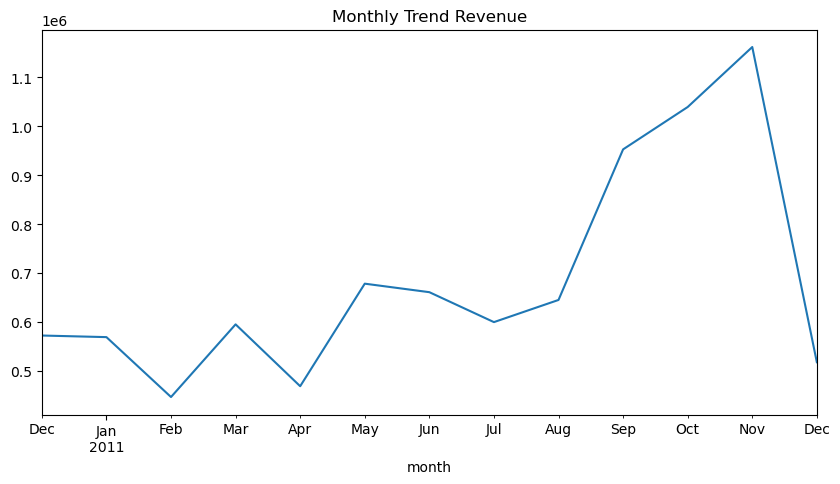

In [75]:
# Create revenue
df['revenue'] = df['quantity'] * df['unitprice']

# Monthly revenue
df['month'] = df['invoicedate'].dt.to_period('M')

monthly_revenue = df.groupby('month')['revenue'].sum()
monthly_revenue.plot(figsize=(10,5), title="Monthly Trend Revenue")

### Insight
- Revenue shows an overall increasing trend over time
- There is noticeable peak toward th end of the year (Q4), suggesting possible seasonal demand
- A sharp drop in the final month may indicate incomplete data rather than actual business decline

### Business Interpreation
- The business experience strong growth, especially in later months
- Marketing and inventory planning should focus on high demand period (Q4)
- Data completeness should be validated for the last month befor making decisions

## SQL Database Creataion
To enable scalable and efficient analysis, the cleaned dataset is stored in a SQLite database.

This allows us to:
- Run SQL queries for business insights
- Simulate real-world data workflows
- Separate data storage from analysis logic


In [76]:
import sqlite3

# Connect to SQLite database (create file if doesn't exist)
conn = sqlite3.connect("../ecommerce.db")

# Convert columns type (period to string) to be compatible with SQLite
for col in df.columns:
    if pd.api.types.is_period_dtype(df[col]):
        df[col] = df[col].astype(str)

# Save cleaned dataframe into database as 'orders' table
df.to_sql("orders", conn, if_exists="replace", index=False)

# Confirm save
print('Data saved to SQLite database successfully.')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_6684\225306317.py:8: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if pd.api.types.is_period_dtype(df[col]):


Data saved to SQLite database successfully.


In [77]:
# SQL query: top countries by revenue
query = """
SELECT
    country,
    ROUND(SUM(revenue),2) AS total_revenue
FROM orders
GROUP BY country
ORDER BY total_revenue DESC
LIMIT 10
"""

# Execute query and load results into pandas
top_countries = pd.read_sql(query, conn)

# Display results
top_countries

,country,total_revenue
0,United Kingdom,7308391.55
1,Netherlands,285446.34
2,EIRE,265545.90
3,Germany,228867.14
4,France,209024.05
5,Australia,138521.31
6,Spain,61577.11
7,Switzerland,56443.95
8,Belgium,41196.34
9,Sweden,38378.33


### Top Countries by Revenue
This analysis identifies the countries generating the highest revenue.

### Insight
- A small number of countries contribute the majority of total revenue
- This indicates a strong geographic concentration of sales
- The business may rely heavily on specific markets

### Business Recommendation
- Focus marketin efforts on top-performing countries
- Explore expansion opportunities in lower-performing regions
- Reduce dependency on a limited number of markets 

## Product Performance Analysis
To understand which products drive revenue, we analyze top-performing products based on total sales.

This helps identify:
- Best-selling products
- Revenue concentration
- Opportunities for optimization

In [78]:
# SQL query: top products by revenue
query = """
SELECT 
    description,
    ROUND(SUM(revenue), 2) AS total_revenue,
    SUM(quantity) AS total_quantity
FROM orders
GROUP BY description
ORDER BY total_revenue DESC
LIMIT 10
"""

# Execute query 
top_products = pd.read_sql(query, conn)

# Display result
top_products


,description,total_revenue,total_quantity
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995
1,REGENCY CAKESTAND 3 TIER,142592.95,12412
2,WHITE HANGING HEART T-LIGHT HOLDER,100448.15,36725
3,JUMBO BAG RED RETROSPOT,85220.78,46181
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916
5,POSTAGE,77803.96,3120
6,PARTY BUNTING,68844.33,15295
7,ASSORTED COLOUR BIRD ORNAMENT,56580.34,35362
8,Manual,53779.93,7179
9,RABBIT NIGHT LIGHT,51346.20,27202


<Axes: ylabel='description'>

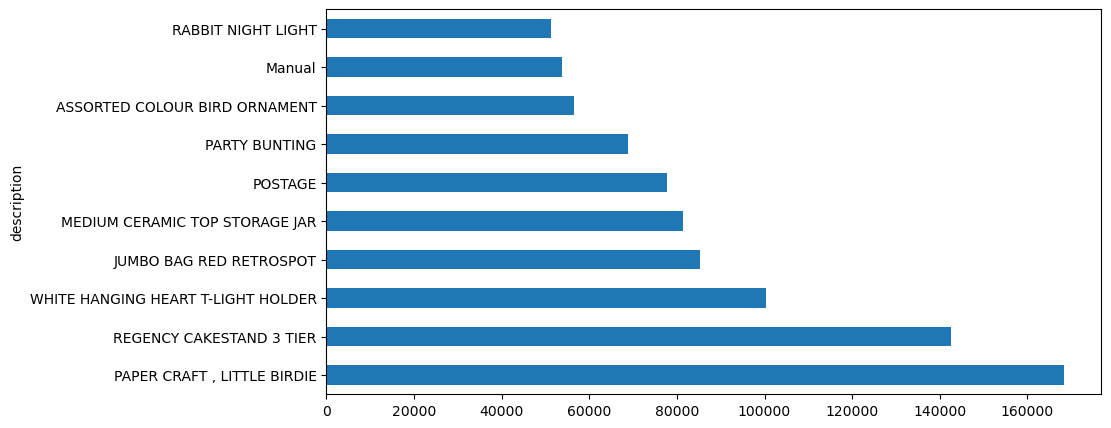

In [79]:
# Plot top products
top_products.set_index("description")["total_revenue"].plot(kind="barh", figsize=(10,5))

### Insight

- A small number of products generate a significant portion of total revenue  
- High-revenue products also tend to have high sales volume  
- This suggests a strong product concentration effect  

### Business Recommendation

- Focus inventory and promotion on top-performing products  
- Analyze why these products perform well (price, demand, category)  
- Identify underperforming products for potential removal or improvement

## Customer Analysis

To better understand customer behavior, we analyze customer-level revenue and identify the highest-value customers.

This helps the business:
- Identify key customers
- Understand revenue concentration
- Support retention strategies

In [80]:
# SQL query: top customers by revenue
query = """
SELECT 
    customerid,
    ROUND(SUM(revenue), 2) AS total_revenue,
    COUNT(DISTINCT invoiceno) AS total_orders
FROM orders
GROUP BY customerid
ORDER BY total_revenue DESC
LIMIT 10
"""

# Execute query
top_customers = pd.read_sql(query, conn)

# Display result
top_customers

,customerid,total_revenue,total_orders
0,14646.0,280206.02,74
1,18102.0,259657.30,60
2,17450.0,194550.79,46
3,16446.0,168472.50,2
4,14911.0,143825.06,201
5,12415.0,124914.53,21
6,14156.0,117379.63,55
7,17511.0,91062.38,31
8,16029.0,81024.84,63
9,12346.0,77183.60,1


<Axes: title={'center': 'Top Customers by Revenue'}, xlabel='customerid'>

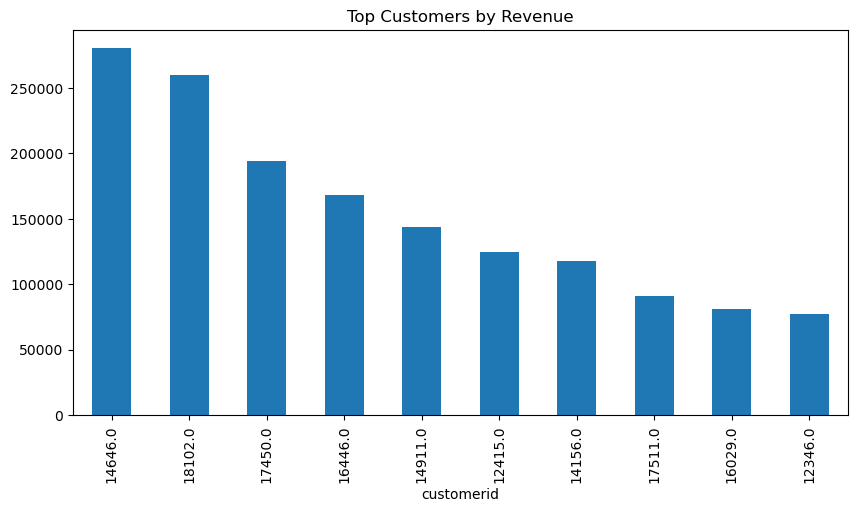

In [81]:
# Plot top customers by revenue
top_customers.set_index("customerid")["total_revenue"].plot(
    kind="bar",
    figsize=(10,5),
    title="Top Customers by Revenue"
)

### Insight

- A small number of customers contribute a large portion of revenue
- Top customers are important for retention and relationship management
- Revenue concentration suggests that losing key customers could impact business performance

### Business Recommendation

The business should prioritize retention strategies for high-value customers through loyalty programs, personalized offers, and targeted engagement.

## Repeat vs New Customers

To understand customer retention, we analyze how many customers return and make multiple purchases.

This helps evaluate:
- Customer loyalty
- Retention performance
- Business sustainability

In [82]:
# SQL: classify customers based on number of orders
query = """
SELECT 
    customerid,
    COUNT(DISTINCT invoiceno) AS total_orders
FROM orders
GROUP BY customerid
"""

customer_orders = pd.read_sql(query, conn)

In [83]:
# classify customers
customer_orders['customer_type'] = customer_orders['total_orders'].apply(
    lambda x: 'Repeat' if x > 1 else 'New'
)

# count
customer_type_count = customer_orders['customer_type'].value_counts()

customer_type_count

customer_type
Repeat    2845
New       1494
Name: count, dtype: int64

<Axes: title={'center': 'New vs Repeat Customers'}, xlabel='customer_type'>

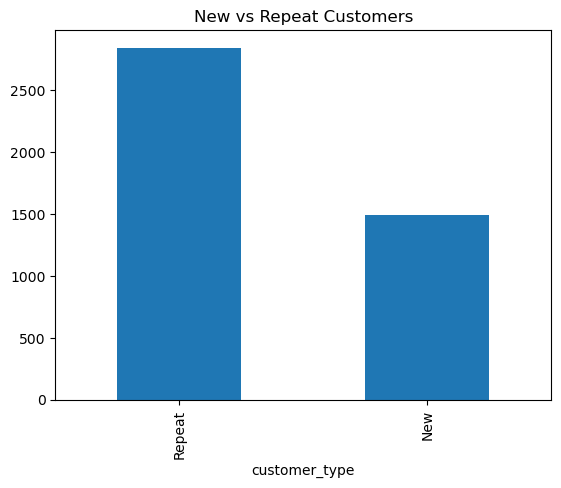

In [84]:
# Visualization
customer_type_count.plot(kind='bar', title='New vs Repeat Customers')

### Insight

- Repeat customers represent a key portion of total customers  
- A higher number of repeat customers indicates strong customer retention  
- If new customers dominate, the business may rely heavily on acquisition rather than retention  

### Business Recommendation

- Improve retention strategies to increase repeat customers  
- Focus on customer experience and loyalty programs  
- Reduce dependency on constant new customer acquisition

---

## Advanced SQL Analysis
In this section, we use advanced SQL techniques to extract deeper business insights from the data.

This includes:
- Customer ranking using window functions
- Identifying high-value customers
- Monthly revenue trends using CTE
- Revenue comparison against average performance

These analyses simulate real-world business scenarios and decision-making.

### Top Customers Ranking (Window Function)

We rank customers based on total revenue using SQL window functions.

This helps identify the most valuable customers driving business revenue.

In [85]:
# SQL: Rank customers by revenue
query = """
SELECT 
    customerid,
    SUM(revenue) AS total_revenue,
    RANK() OVER (ORDER BY SUM(revenue) DESC) AS customer_rank
FROM orders
GROUP BY customerid
LIMIT 10;
"""

# Execute query
top_customers_ranked = pd.read_sql(query, conn)

# Display result
top_customers_ranked

,customerid,total_revenue,customer_rank
0,14646.0,280206.02,1
1,18102.0,259657.30,2
2,17450.0,194550.79,3
3,16446.0,168472.50,4
4,14911.0,143825.06,5
5,12415.0,124914.53,6
6,14156.0,117379.63,7
7,17511.0,91062.38,8
8,16029.0,81024.84,9
9,12346.0,77183.60,10


### Insight
- Revenue is highly concentrated among top-ranked customers
- The top 10 customers contribute a disproportionately large share of total revenue
- This indicates a strong dependency on a small customer segment

**Business Impact:**
- High risk if top customers churn
- Opportunity to build loyalty programs for top-tier customers
- Suggests need for customer segmentation (VIP strategy)

---

### High-Value Transactions (Above Average Revenue)

We identify transactions where revenue is above the average.

This helps detect high-value orders that contribute significantly to revenue.

In [86]:
# SQL: Find transactions above average revenue
query = """
SELECT *
FROM orders
WHERE revenue > (
    SELECT AVG(revenue) FROM orders
)
LIMIT 10;
"""

high_value_orders = pd.read_sql(query, conn)
high_value_orders

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,revenue,month
0,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50,2010-12
1,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08,2010-12
2,536367,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,8,2010-12-01 08:34:00,3.75,13047.0,United Kingdom,30.00,2010-12
3,536367,84969,BOX OF 6 ASSORTED COLOUR TEASPOONS,6,2010-12-01 08:34:00,4.25,13047.0,United Kingdom,25.50,2010-12
4,536367,21777,RECIPE BOX WITH METAL HEART,4,2010-12-01 08:34:00,7.95,13047.0,United Kingdom,31.80,2010-12
5,536367,48187,DOORMAT NEW ENGLAND,4,2010-12-01 08:34:00,7.95,13047.0,United Kingdom,31.80,2010-12
6,536368,22960,JAM MAKING SET WITH JARS,6,2010-12-01 08:34:00,4.25,13047.0,United Kingdom,25.50,2010-12
7,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.75,12583.0,France,90.00,2010-12
8,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.75,12583.0,France,90.00,2010-12
9,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.75,12583.0,France,45.00,2010-12


### Insight
- A subset of transactions exceeds the average revenue significantly
- These high-value orders contribute heavily to overall revenue performance
- Not all customers behave equally — presence of premium purchasing behavior

**Business Impact:**
- Opportunity to target high-spending customers with personalized offers
- Potential for upselling and bundling strategies
- Helps define premium customer segments

### Monthly Revenue Trend (CTE)

We use a Common Table Expression (CTE) to calculate monthly revenue.

This allows us to analyze trends and identify growth periods.

<Axes: title={'center': 'Monthly Revenue (SQL)'}, xlabel='month'>

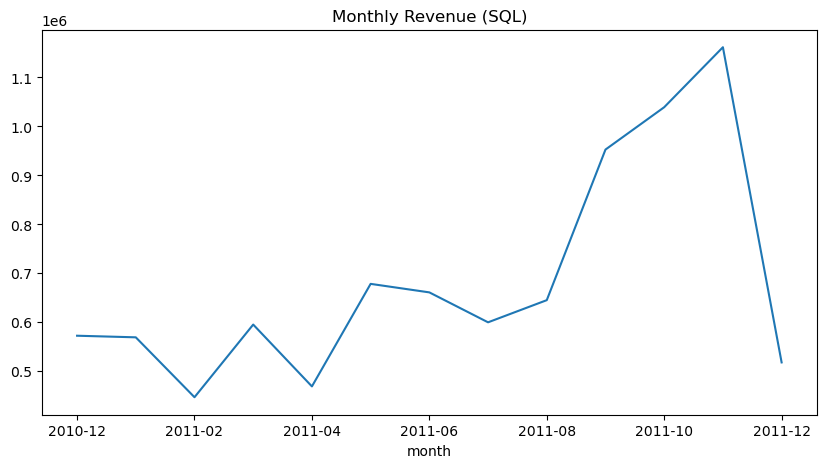

In [87]:
# SQL: Monthly revenue using CTE
query = """
WITH monthly_revenue AS (
    SELECT 
        strftime('%Y-%m', invoicedate) AS month,
        SUM(revenue) AS total_revenue
    FROM orders
    GROUP BY month
)
SELECT *
FROM monthly_revenue
ORDER BY month;
"""

monthly_sql = pd.read_sql(query, conn)

# Plot
monthly_sql.set_index("month")["total_revenue"].plot(figsize=(10,5), title="Monthly Revenue (SQL)")

### Insight
- Revenue shows a clear upward trend over time with noticeable fluctuations
- Peak revenue occurs in later months, indicating possible seasonal demand
- Sharp drop at the end may indicate incomplete data or post-season decline

**Business Impact:**
- Supports seasonal marketing and sales planning
- Helps forecast demand and optimize inventory
- Enables better budgeting and campaign timing

---

## Final Business Summary

This project analyzes e-commerce sales data to uncover key business insights related to revenue, customer behavior, and product performance.

### Key Findings

- Revenue is highly concentrated among a small number of customers, indicating strong dependency on high-value customers.
- A limited set of products generates a significant portion of total revenue, suggesting a product concentration effect.
- Monthly revenue trends show clear growth patterns with fluctuations, indicating potential seasonality in sales.
- High-value transactions (above average revenue) play a critical role in overall business performance.

### Business Implications

- The business should prioritize retention strategies for high-value customers.
- Top-performing products should be promoted and optimized for inventory and marketing.
- Seasonal trends can guide marketing campaigns and demand forecasting.
- Identifying high-value transactions can support pricing and bundling strategies.

### Conclusion

By combining Python analysis with advanced SQL techniques, this project demonstrates how raw data can be transformed into actionable business insights to support decision-making.